# 02 EDA

Denne notebooken lager en enkel, konsistent EDA pa dagsdata:
- laster data via utils
- bygger analyseklar dataframe
- sjekker manglende verdier
- lager histogrammer for malvariabler og drivere
- validerer nyhetsbrev_b7-fordeling

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")

project_root = Path.cwd().resolve().parent.parent
code_dir = project_root / "code"
if str(code_dir) not in sys.path:
    sys.path.append(str(code_dir))

from utils.data_load import load_raw_data
from utils.data_prep import data_prep

In [2]:
# Last data
NEWSLETTER_CSV = project_root / "data" / "newsletter_sendouts.csv"

df_inngang, df_info, df_weather = load_raw_data(
    session=None,
    weather_path=project_root / "data" / "oslo_weather.csv",
)

df = data_prep(
    df_inngang=df_inngang,
    df_info=df_info,
    df_weather=df_weather,
    cols_to_remove=None,
    newsletter_dates_csv=str(NEWSLETTER_CSV),
)

print("Prepared shape:", df.shape)
print("Dato fra/til:", df["ankomst_dato"].min(), "->", df["ankomst_dato"].max())
df.head(3)

Prepared shape: (500, 132)
Dato fra/til: 2024-06-03 -> 2026-06-02


,ankomst_dato,antall_samtaler,behandlet_andel,tid_i_ko_snitt,behandlingstid_snitt,total_behandlingstid,etterbehandligstid_snitt,total_etterbehandligstid,hf_dato,antall_nye_kunder_b30_mpb01_ny,...,tempavvik_fra_mndsnitt,antall_nye_kunder_b30_ny,antall_nye_kunder_b30_for,antall_hf_b30_ny,antall_hf_b30_for,stddev_premieendring_b30_for,snitt_premieendring_b30_for,antall_nye_kunder_b30_tot,antall_hf_b30_tot,nyhetsbrev_b7
0,2024-06-03,181,0.850829,274.342541,281.049724,50870,130.419890,23606,2024-06-03,501,...,3.28,715.0,715.0,4647.0,14805.0,5.613229,1.103433,1430.0,19452.0,1
1,2024-06-04,408,0.828431,732.632353,280.009804,114244,121.987745,49771,2024-06-04,502,...,-0.62,704.0,704.0,4610.0,14874.0,5.590825,1.104086,1408.0,19484.0,1
2,2024-06-05,294,0.782313,650.248299,258.166667,75901,97.272109,28598,2024-06-05,488,...,-2.62,687.0,687.0,4564.0,14925.0,5.584061,1.104388,1374.0,19489.0,1


In [3]:
# Manglende verdier
missing = df.isna().sum().sort_values(ascending=False)
missing = missing[missing > 0]

print("Kolonner med manglende verdier:", len(missing))
missing.head(25)

Kolonner med manglende verdier: 13


helligdag                         480
antall_hf_b30_epf01_ny             44
antall_nye_kunder_f7_epf01_ny      44
antall_hf_b7_epf01_ny              44
antall_hf_b30_tot                  44
antall_nye_kunder_b30_tot          44
antall_nye_kunder_b30_ny           44
antall_hf_b30_ny                   44
antall_hf_f7_epf01_ny              44
antall_nye_kunder_b30_epf01_ny     44
antall_nye_kunder_f30_epf01_ny     44
antall_hf_f30_epf01_ny             44
antall_nye_kunder_b7_epf01_ny      44
dtype: int64

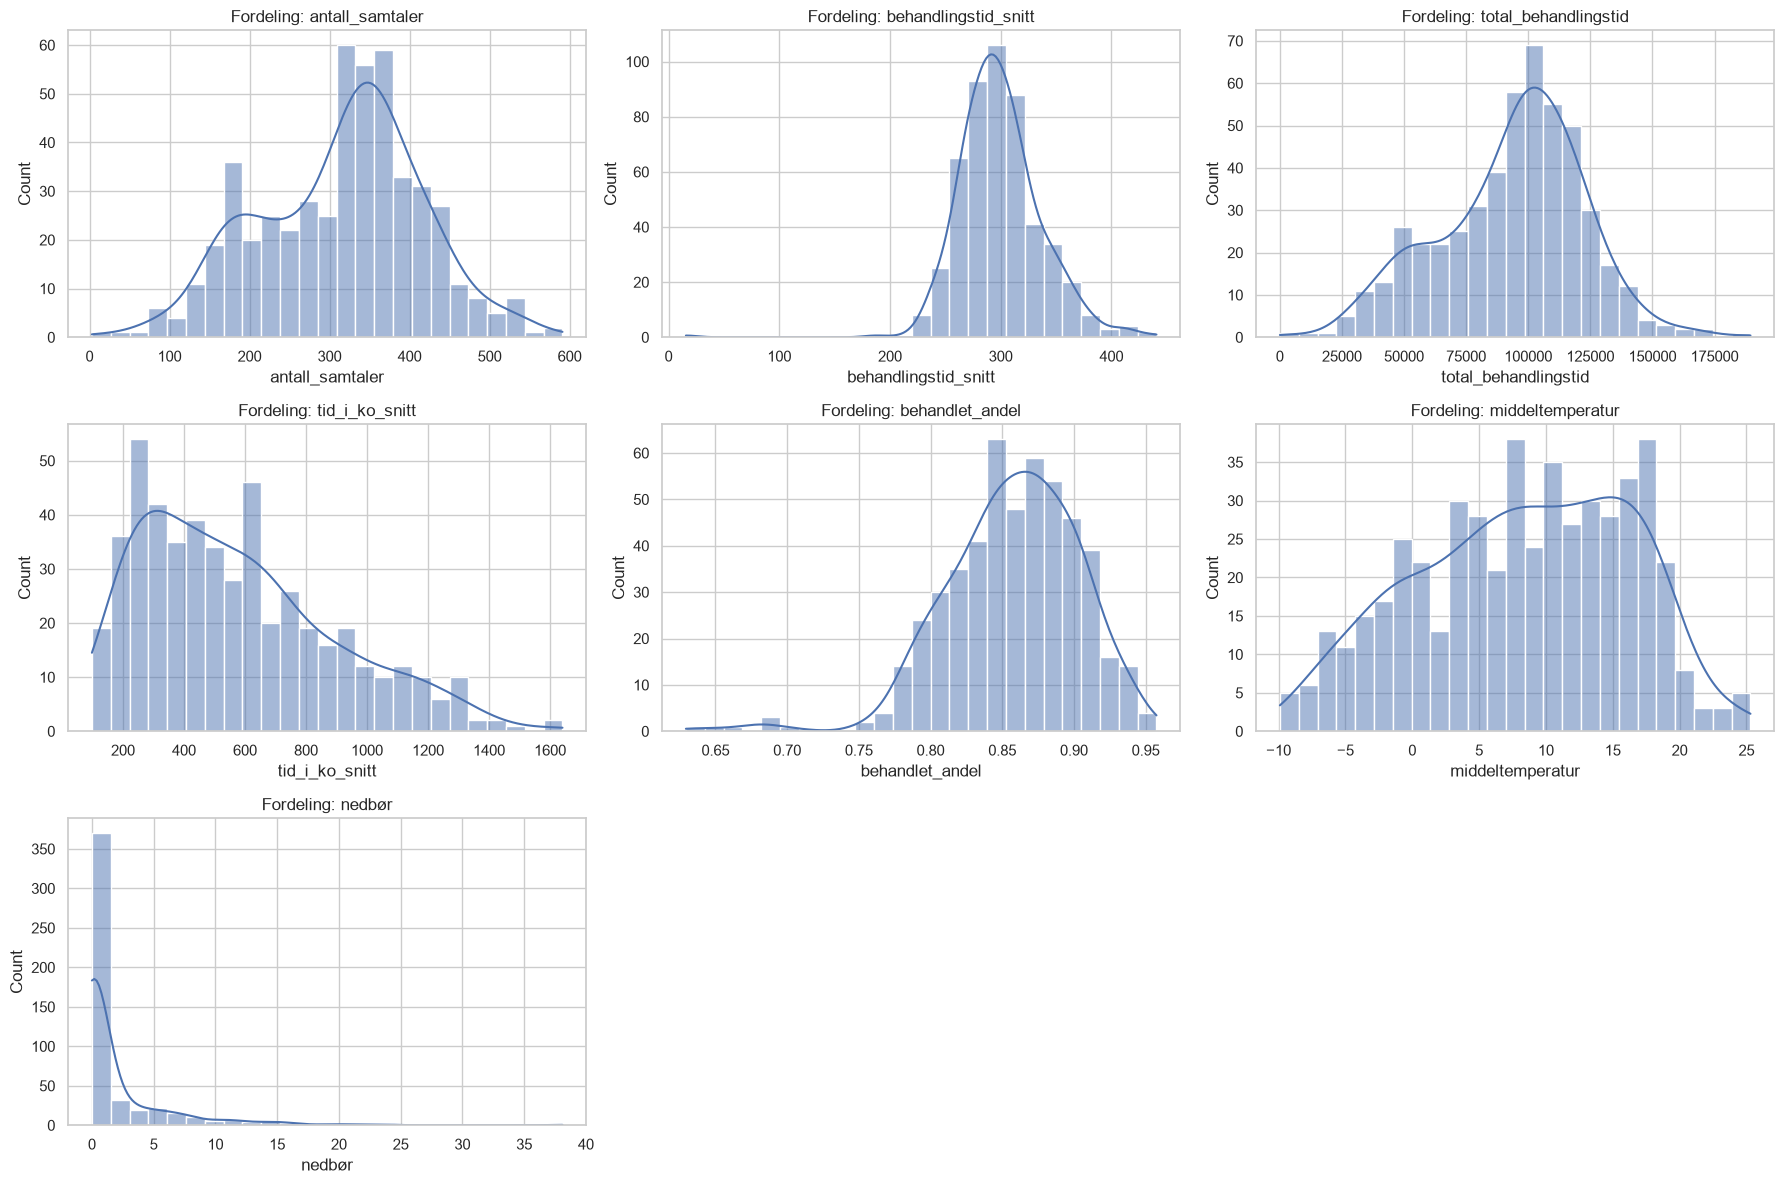

In [4]:
# Histogrammer: malvariabler + drivere
hist_cols = [
    "antall_samtaler",
    "behandlingstid_snitt",
    "total_behandlingstid",
    "tid_i_ko_snitt",
    "behandlet_andel",
    "middeltemperatur",
    "nedbør",
]

available_hist_cols = [col for col in hist_cols if col in df.columns]

n = len(available_hist_cols)
ncols = 3
nrows = (n + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 4 * nrows))
axes = axes.flatten() if n > 1 else [axes]

for i, col in enumerate(available_hist_cols):
    sns.histplot(df[col].dropna(), bins=25, kde=True, ax=axes[i], color="#4C72B0")
    axes[i].set_title(f"Fordeling: {col}")
    axes[i].set_xlabel(col)

for j in range(n, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

nyhetsbrev_b7
0    384
1    116
Name: count, dtype: int64


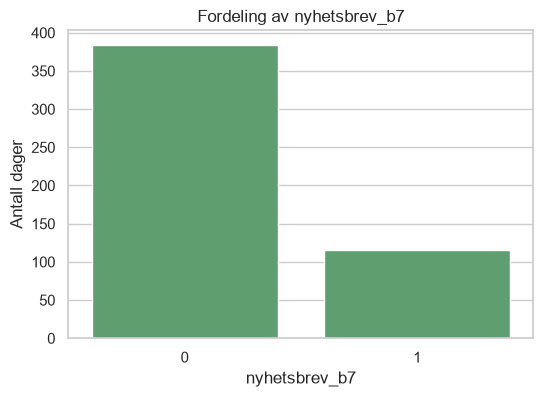

In [5]:
# Fordeling av nyhetsbrev_b7 (0/1)
if "nyhetsbrev_b7" in df.columns:
    counts = df["nyhetsbrev_b7"].value_counts(dropna=False).sort_index()
    print(counts)

    plt.figure(figsize=(6, 4))
    sns.countplot(x=df["nyhetsbrev_b7"], color="#55A868")
    plt.title("Fordeling av nyhetsbrev_b7")
    plt.xlabel("nyhetsbrev_b7")
    plt.ylabel("Antall dager")
    plt.show()
else:
    print("Kolonnen nyhetsbrev_b7 finnes ikke i df.")

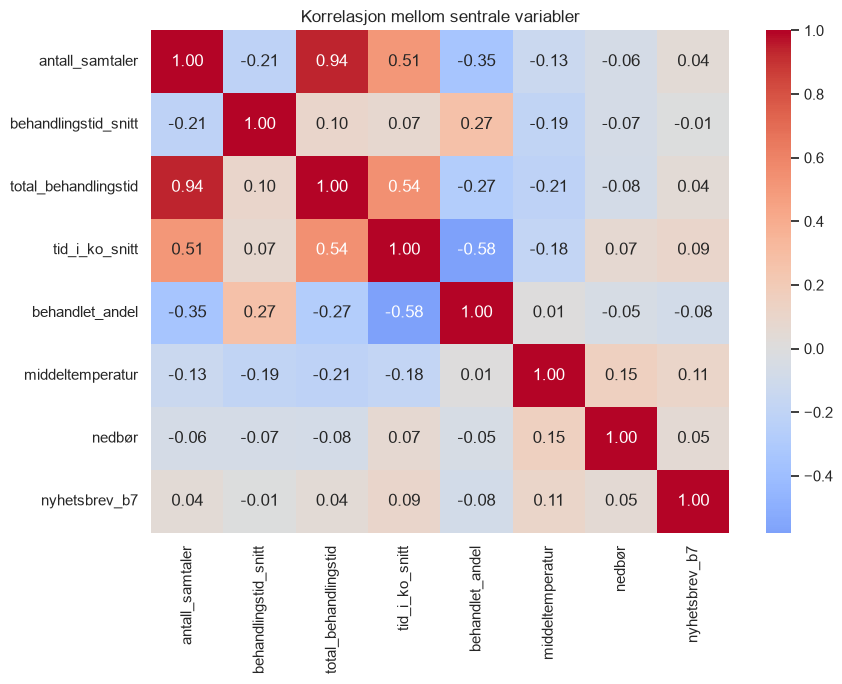

In [6]:
# Enkel korrelasjonsoversikt for sentrale numeriske kolonner
corr_cols = [
    "antall_samtaler",
    "behandlingstid_snitt",
    "total_behandlingstid",
    "tid_i_ko_snitt",
    "behandlet_andel",
    "middeltemperatur",
    "nedbør",
    "nyhetsbrev_b7",
]

corr_cols = [col for col in corr_cols if col in df.columns]
corr = df[corr_cols].corr(numeric_only=True)

plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Korrelasjon mellom sentrale variabler")
plt.tight_layout()
plt.show()